# Carbon Mapper products

How to consume Carbon Mapper data at every product level via the
georeader reader subpackage. One section per resource type, each
showing the typed model, the asset wrapper, and a worked example
with inline plots:

| § | Resource | Wrapper | Headline asset |
|---|---|---|---|
| 1 | **Plume** — one detection | `CMRawPlume` (typed metadata) | catalog dict + asset URLs |
| 2 | **Image** — per-plume products | `CMPlumeImage` (this PR's headline) | mask, concentrations, ime, rgb, outline |
| 3 | **Tile** — L2B scene | `CMImageRaster` | cmf retrieval + RGB sibling |
| 4 | **Source** — DBSCAN cluster | `CMSource` | source-aggregated plume stats |

**CH4 only in this notebook.** The reader is gas-agnostic
internally, but query helpers are typed `Literal["CH4"]` for now;
CO2 lands in a follow-up.

Companion: [`api_explore.ipynb`](api_explore.ipynb) — the typed
query layer in depth (REST + STAC surfaces, filter map, exception
hierarchy).


## Install

```
pip install 'georeader-spaceml[carbonmapper]'
```

Includes `pydantic`, `requests`, and the standard rasterio /
shapely dependencies. The wrappers go through
`georeader.RasterioReader` for the actual GeoTIFF I/O — no
extras beyond the base `[carbonmapper]` extra.


## Setup

`CarbonMapperConfig.load()` resolves a Bearer token from env
(`CARBONMAPPER_TOKEN`, or `CARBONMAPPER_EMAIL`+`PASSWORD`) or one
of the standard config-file paths — see
[`api_explore.ipynb#authentication`](api_explore.ipynb#authentication).

Carbon Mapper's STAC asset URLs are also gated by the same token,
so we push it into GDAL's curl session here. `RasterioReader`
goes through `rasterio` → GDAL → libcurl, which reads the env var.


In [1]:
import os

from georeader.readers.carbonmapper import (
    CarbonMapperConfig,
    Collection,
    Gas,
    Instrument,
    api_queries,
)

TOKEN = CarbonMapperConfig.load().refresh_access_token()

# RasterioReader streams over GDAL/libcurl. Push the token in once.
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {TOKEN}"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.TIF"
# Retry on transient HTTP failures (5xx + 429) — the CarbonMapper
# CDN occasionally rate-limits tight read sequences. GDAL's built-in
# retry hides those from rasterio.
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "3"   # seconds (exponential)

# Protagonist plume — Permian basin, December 2025 (v3b processing).
PLUME_ID = "tan20251212t185057c20s4001-E"
print(f"plume_id = {PLUME_ID}")
print(f"Collection.L3A_VIS_V3A.is_stac_resident = {Collection.L3A_VIS_V3A.is_stac_resident}")
print(f"Collection.L3A_VIS_V3C.is_stac_resident = {Collection.L3A_VIS_V3C.is_stac_resident}")


plume_id = tan20251212t185057c20s4001-E
Collection.L3A_VIS_V3A.is_stac_resident = True
Collection.L3A_VIS_V3C.is_stac_resident = False


## Products inventory — what's reachable per plume

Static reference — no API calls. The same content lives in the PR plan;
mirrored here so the notebook is self-contained.

### Per-plume assets (L3A vis + ime collections)

12 reachable assets per CH4 plume. CMPlumeImage exposes 7 of them
as lazy properties; the 5 PNG variants are decimated thumbnails
(strictly smaller than the matching GeoTIFFs) and intentionally
not wrapped — there's no native georeferencing on a PNG.

| Asset | Format | What it is | CMPlumeImage property |
|---|---|---|---|
| `plume.tif` | GeoTIFF (RGBA) | Mask raster — band 4 alpha = broader plume mask | **`mask`** |
| `plume-concentrations.tif` | GeoTIFF (1-band) | CH4 column density crop (full per-plume window) | **`concentrations`** |
| `ime-cmf-concentrations.tif` | GeoTIFF (1-band) | IME-clipped column density (only mask-significant pixels) | **`ime_concentrations`** |
| `ime-cmf-mask.tif` | GeoTIFF (1-band) | IME-significance binary mask (subset of `mask`) | **`ime_mask`** |
| `rgb.tif` | GeoTIFF (3-band) | True-colour context (widest extent of all per-plume assets) | **`rgb`** |
| `plume-outline.geojson` | GeoJSON | Broader plume polygon (canonical) | **`outline`** |
| `ime-cmf-outline.geojson` | GeoJSON | Tighter IME-significant polygon | **`ime_outline`** |
| `plume.png` | PNG | Decimated viz of `plume.tif` | _(not wrapped)_ |
| `plume-rgb.png` | PNG | Plume mask overlaid on RGB | _(not wrapped)_ |
| `rgb.png` | PNG | Decimated viz of `rgb.tif` | _(not wrapped)_ |
| `ime-cmf-concentrations.png` | PNG | Decimated viz | _(not wrapped)_ |
| `ime-cmf-mask.png` | PNG | Decimated viz | _(not wrapped)_ |

For a wider scene-level concentration view, use the L2B
`CMImageRaster.cmf` from the parent tile (§ 3) — there is **no**
wider concentration product at the plume level.

### Native extents (verified for one v3a plume)

Each asset has a different native size — Carbon Mapper crops them
at different scales:

| Asset | Pixels | Approx. ground span |
|---|---|---|
| `plume.tif` / `rgb.tif` | 101 × 100 | 3030m × 3000m (widest — full context window) |
| `plume-concentrations.tif` | 41 × 48 | 1230m × 1440m (per-plume crop) |
| `ime-cmf-concentrations.tif` | 11 × 11 | 330m × 330m (IME-significant only — tightest) |
| PNG variants | 6×3 to 115×115 | n/a (decimated thumbnails) |

This asymmetry is why the §2.4 visualization locks all panels to
a common viewport (rgb dominates).

### Version timeline (active CH4 product families)

Carbon Mapper bumps `emission_version` per processing-software
release. `v3a` is the canonical STAC-exposed version family;
`v3c` is the live processing version of newer plumes (post
2026-01) but is **not** registered in `/stac/collections`.
`CMPlumeImage.from_plume_id` handles both transparently via
URL-pattern derivation.

| Version | In STAC? | Item count (cmf-mfa) | Earliest | Latest | Notes |
|---|---|---|---|---|---|
| `mf-v1` | ✅ | 8,487 (L2B) | 2016-09-10 | 2024-06-12 | First public release; legacy schema |
| `mfa-v1` | ✅ | 24,786 (L2B) | 2017-06-18 | 2025-03-04 | Mass-Flux-Adjusted retrieval |
| `mfa-v3` | ✅ | 35,900 (L2B) | 2014-10-05 | 2025-11-11 | Largest single version; current STAC schema |
| **`mfa-v3a`** | ✅ | **1,675 (L2B)** | **2025-07-11** | **2025-12-16** | **Canonical current — STAC-exposed** |
| `v3b` | ❌ | (REST URLs only) | early 2026 | early 2026 | Intermediate, not in STAC |
| **`v3c`** | ❌ | (REST URLs only) | 2026-01 | live | **Newest — REST URLs only, NOT in STAC** |

`v3a` and `v3c` cover *different plumes* (not different versions
of the same plumes). `v3a` is a curated 2025-07 → 2025-12
snapshot; `v3c` is the rolling forward processing of plumes from
2026-01 onward.


## 1 · Plumes — typed metadata

`CMRawPlume` is the typed view of one Carbon Mapper detection. The
headline metric is `emission_auto` (kg/h); everything else
(emission uncertainty, wind, geometry, sector, instrument) is
ancillary.

Two derived properties bridge plumes to the other entities below:

- **`scene_id`** — `plume_id.rsplit('-', 1)[0]`. The L2B item id
  in `Collection.L2B_V3A`. Use this to navigate from a plume to
  its parent tile (§3) without an HTTP round-trip.
- **`version`** — re-exposes `emission_version` (`"v3a"` /
  `"v3b"` / `"v3c"`). Branch on this to choose between STAC item
  lookup (v3a) and URL-pattern derivation (v3c, see §2).


In [2]:
plume = api_queries.get_plume(TOKEN, PLUME_ID)

print(f"plume_id        : {plume.plume_id}")
print(f"gas             : {plume.gas}")
print(f"instrument      : {plume.instrument}  → {plume.instrument_name}")
print(f"version         : {plume.version}")
print(f"scene_id        : {plume.scene_id}     ← derived (rsplit)")
print(f"scene_uuid      : {plume.scene_uuid}    ← API's internal UUID")
print(f"emission_auto   : {plume.emission_auto:>9.1f} kg/h")
print(f"wind (u, v)     : ({plume.wind_u:.2f}, {plume.wind_v:.2f}) m/s")
print(f"sector          : {plume.sector}")


plume_id        : tan20251212t185057c20s4001-E
gas             : CH4
instrument      : tan  → Tanager-1
version         : v3b
scene_id        : tan20251212t185057c20s4001     ← derived (rsplit)
scene_uuid      : 64a51834-5fe5-40e0-aadd-e0c5944850c3    ← API's internal UUID
emission_auto   :    1007.7 kg/h
wind (u, v)     : (0.87, -4.27) m/s
sector          : 1B2


### 1.1 Enums for constrained value sets

Three `StrEnum`s expose Carbon Mapper's closed value sets. They
satisfy `str` so they're drop-in for any string parameter, but
typed checking + IDE autocomplete come for free.


In [3]:
print(f"Gas:        {[g.value for g in Gas]}")
print(f"Instrument: {[i.value for i in Instrument]}")
print()

# Instrument is case-insensitive on construction (the upstream API
# is mixed-case — `tan` lowercase, `GAO` uppercase — and `_missing_`
# normalises).
for variant in ("tan", "TAN", "Tan", "gao", "GAO"):
    print(f"  Instrument({variant!r:>5}) → {Instrument(variant)}")


Gas:        ['CH4', 'CO2']
Instrument: ['tan', 'emi', 'ang', 'av3', 'GAO']

  Instrument('tan') → tan
  Instrument('TAN') → tan
  Instrument('Tan') → tan
  Instrument('gao') → GAO
  Instrument('GAO') → GAO


### 1.2 `list_plumes` — typed, filterable, paginated

The default consumer surface for plume discovery. `gas` is typed
`Gas | Literal["CH4"]` so plain `gas="CH4"` calls keep
type-checking.


In [4]:
from datetime import datetime, timezone

PERMIAN = (-104.5, 32.0, -103.5, 32.8)
plumes = api_queries.list_plumes(
    TOKEN,
    bbox=PERMIAN,
    instruments=["tan"],
    datetime_min=datetime(2025, 12, 1, tzinfo=timezone.utc),
    datetime_max=datetime(2025, 12, 31, tzinfo=timezone.utc),
    gas=Gas.CH4,
    limit=20,
)
print(f"{len(plumes)} CH4 Tanager plumes in Permian (Dec 2025)\n")
for p in plumes[:5]:
    print(
        f"  {p.plume_id}  emission={p.emission_auto:>7.0f} kg/h  "
        f"sector={p.sector}  version={p.version}"
    )


20 CH4 Tanager plumes in Permian (Dec 2025)

  tan20251212t185057c20s4001-C  emission=    876 kg/h  sector=1B2  version=v3b
  tan20251212t185057c20s4001-D  emission=    433 kg/h  sector=1B2  version=v3b
  tan20251212t185057c20s4001-E  emission=   1008 kg/h  sector=1B2  version=v3b
  tan20251212t185057c20s4001-G  emission=    521 kg/h  sector=1B2  version=v3c
  tan20251212t185057c20s4001-I  emission=    418 kg/h  sector=1B2  version=v3d


## 2 · Images — per-plume product bundle

`CMPlumeImage` wraps every reachable per-plume L3A asset as a
lazy property:

| Property | Asset | Type | Notes |
|---|---|---|---|
| `mask` | `plume.tif` | `RasterioReader` (RGBA) | Band 4 alpha = broader plume mask |
| `concentrations` | `plume-concentrations.tif` | `RasterioReader` | Per-plume column-density crop (full) |
| `ime_concentrations` | `ime-cmf-concentrations.tif` | `RasterioReader` | IME-clipped column density — **the data CM integrated for `emission_auto`** |
| `ime_mask` | `ime-cmf-mask.tif` | `RasterioReader` | IME-significant binary mask — tighter subset of `mask` |
| `rgb` | `rgb.tif` | `RasterioReader` | True-colour context (3-band) |
| `outline` | `plume-outline.geojson` | `shapely.MultiPolygon` | Broader plume polygon (canonical) |
| `ime_outline` | `ime-cmf-outline.geojson` | `shapely.MultiPolygon` | Tighter IME-significant polygon |

PNG variants (`plume.png`, `plume-rgb.png`, `rgb.png`,
`ime-cmf-concentrations.png`, `ime-cmf-mask.png`) are
intentionally **not** wrapped — Carbon Mapper publishes them as
decimated thumbnails for visualisation, not georeferenced data.
The matching `.tif` is always strictly larger and
georeferenced.

**Key design choices:**

- **Outline canonical** — `outline` fetches the GeoJSON; falls
  back to vectorising band-4 alpha (with a warning) only on fetch
  failure. `ime_outline` returns `None` rather than
  vectorising — the broader `outline` is the safety net.
- **v3a + v3c handled transparently** — `from_plume_id` derives
  every asset URL from the catalog `plume_tif` URL via a
  version-agnostic regex swap. Works for v3a (STAC-resident),
  v3b (intermediate), and v3c (CDN-only).
- **Seven lazy properties** — opening one doesn't open the
  others. Each is cached after first access.

**No other concentration GeoTIFF exists at the plume level.** The
two above (`concentrations` + `ime_concentrations`) are it. For
a wider scene-level concentration view, use `CMImageRaster.cmf`
from the parent tile (see § 3).


### 2.1 Construction — three entry points

`from_plume_id` (one HTTP round-trip), `from_cmrawplume` (zero
HTTP if you already have the typed plume), and `from_stac_item`
(driving STAC search directly; v3a only).


In [5]:
from georeader.readers.carbonmapper import CMPlumeImage

# Option A — from a plume_id (one HTTP, handles v3a / v3b / v3c)
img = CMPlumeImage.from_plume_id(PLUME_ID, token=TOKEN)
print(img)


CMPlumeImage
  plume_id:       tan20251212t185057c20s4001-E
  assets present: ['plume.tif', 'plume-concentrations.tif', 'plume-outline.geojson', 'rgb.tif', 'ime-cmf-concentrations.tif', 'ime-cmf-mask.tif', 'ime-cmf-outline.geojson']
  overview_level: full


### 2.2 Properties — what's reachable

URL derivation already happened in `from_plume_id` (one HTTP for
the catalog metadata, then 7 URLs derived locally — no further
network I/O until you access a property). The actual rasterio
reads happen in §2.4 below.


In [6]:
# Inventory the URLs CMPlumeImage built. Properties are lazy —
# none of these have opened a raster yet.
from georeader.readers.carbonmapper.image import CM_PLUME_IMAGE_ASSETS

print(f"{'asset':32s} URL?")
print("-" * 38)
for asset in CM_PLUME_IMAGE_ASSETS:
    print(f"  {asset:30s} {'yes' if asset in img.urls else 'no'}")


asset                            URL?
--------------------------------------
  plume.tif                      yes
  plume-concentrations.tif       yes
  plume-outline.geojson          yes
  rgb.tif                        yes
  ime-cmf-concentrations.tif     yes
  ime-cmf-mask.tif               yes
  ime-cmf-outline.geojson        yes


### 2.3 Outlines — broader vs IME-tight

Two polygon products in EPSG:4326:

- **`outline`** — broader plume polygon, canonical from
  `plume-outline.geojson`. Falls back to vectorising the band-4
  alpha of `mask` (with a warning) on fetch failure.
- **`ime_outline`** — tighter, the polygon Carbon Mapper actually
  integrated over for `emission_auto`. Excludes pixels below the
  IME detection threshold. Returns `None` on fetch failure
  rather than vectorising — the broader outline is the safety net.


In [7]:
def show(name, geom):
    if geom is None:
        print(f"{name:14s}  (absent)")
        return
    print(f"{name:14s}  area={geom.area:.6e} deg²  bounds={tuple(round(b, 4) for b in geom.bounds)}")


show("outline:",     img.outline)
show("ime_outline:", img.ime_outline)


outline:        area=6.307290e-05 deg²  bounds=(-104.177, 32.4778, -104.1687, 32.4927)


ime_outline:    area=4.925074e-06 deg²  bounds=(-104.1761, 32.4878, -104.1732, 32.4919)


### 2.4 Visualise — every per-plume product with the outline overlaid

A 4-panel figure with the canonical `plume-outline.geojson`
overlaid on every panel:

1. **mask** — `plume.tif` band-4 alpha (the binary plume mask).
2. **concentrations** — full per-plume crop from
   `plume-concentrations.tif`.
3. **ime_concentrations** — IME-clipped retrieval from
   `ime-cmf-concentrations.tif` (only mask-significant pixels —
   the data used to compute `emission_auto`).
4. **rgb** — true-colour context from `rgb.tif`.

Carbon Mapper publishes each asset with a different native
extent — `plume.tif` and `plume-concentrations.tif` are tightly
cropped to the plume; `ime-cmf-concentrations.tif` is slightly
wider; `rgb.tif` is the full context window. To read panels
side-by-side, we lock matplotlib's `xlim` / `ylim` across all
four to the widest available extent (rgb's bounds), so the plume
sits inside each panel rather than filling it.


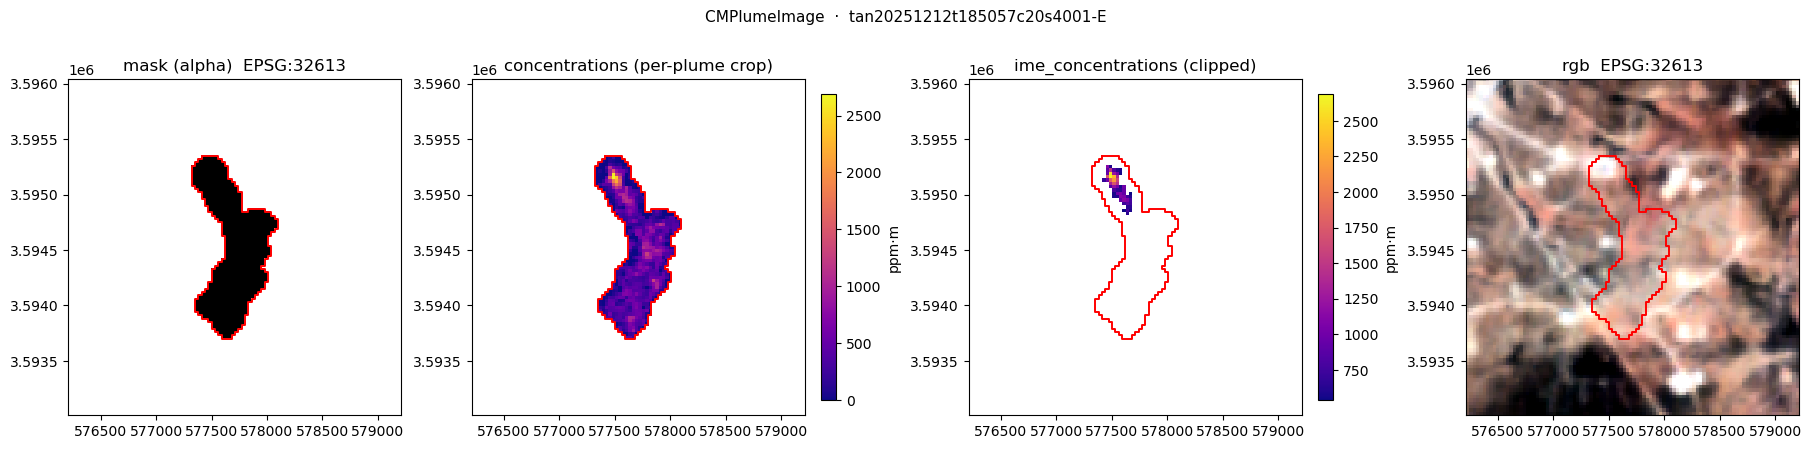

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
from shapely.ops import transform as shp_transform


def _plot_outline(ax, geom_4326, dst_crs):
    """Reproject outline into dst_crs and stroke it."""
    if geom_4326 is None:
        return
    tr = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    g = shp_transform(tr.transform, geom_4326)
    polys = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    for p in polys:
        x, y = p.exterior.xy
        ax.plot(x, y, color="red", lw=1.4, solid_capstyle="round")


# Pick the widest available extent (rgb is widest by CM convention)
# and lock all panels' xlim/ylim to it for visual consistency.
target_crs = None
xmin = ymin = float("inf")
xmax = ymax = float("-inf")
for reader in (img.mask, img.concentrations, img.ime_concentrations, img.rgb):
    if reader is None:
        continue
    b = reader.bounds
    target_crs = target_crs or str(reader.crs)
    xmin, ymin = min(xmin, b[0]), min(ymin, b[1])
    xmax, ymax = max(xmax, b[2]), max(ymax, b[3])
common_xlim = (xmin, xmax)
common_ylim = (ymin, ymax)


import time

# Refresh token + light throttling before the multi-raster reads
# below — the api gateway sometimes rate-limits tight read bursts.
fresh = CarbonMapperConfig.load().refresh_access_token()
import os
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {fresh}"

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), constrained_layout=True)

# (a) mask — band 4 alpha
time.sleep(1); mask_geo = img.mask.load()
mask_arr = np.asarray(mask_geo.values)
alpha = (mask_arr[3] > 0).astype("uint8") if mask_arr.shape[0] >= 4 else mask_arr.squeeze()
bx = mask_geo.bounds
axes[0].imshow(
    alpha,
    extent=(bx[0], bx[2], bx[1], bx[3]),
    origin="upper", cmap="Greys", interpolation="nearest",
)
_plot_outline(axes[0], img.outline, str(mask_geo.crs))
axes[0].set_title(f"mask (alpha)  {mask_geo.crs}")

# (b) concentrations — full per-plume crop from plume-concentrations.tif
time.sleep(1); con_geo = img.concentrations.load()
con_arr = np.asarray(con_geo.values).squeeze().astype("float32")
nd = img.concentrations.nodata
if nd is not None:
    con_arr = np.where(con_arr == nd, np.nan, con_arr)
bx = con_geo.bounds
im = axes[1].imshow(
    con_arr,
    extent=(bx[0], bx[2], bx[1], bx[3]),
    origin="upper", cmap="plasma",
)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="ppm·m")
_plot_outline(axes[1], img.outline, str(con_geo.crs))
axes[1].set_title("concentrations (per-plume crop)")

# (c) IME concentrations (mask-clipped, per-plume)
if img.ime_concentrations is not None:
    time.sleep(1); ime_geo = img.ime_concentrations.load()
    ime_arr = np.asarray(ime_geo.values).squeeze().astype("float32")
    nd = img.ime_concentrations.nodata
    if nd is not None:
        ime_arr = np.where(ime_arr == nd, np.nan, ime_arr)
    bx = ime_geo.bounds
    im = axes[2].imshow(
        ime_arr,
        extent=(bx[0], bx[2], bx[1], bx[3]),
        origin="upper", cmap="plasma",
    )
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="ppm·m")
    _plot_outline(axes[2], img.outline, str(ime_geo.crs))
    axes[2].set_title("ime_concentrations (clipped)")
else:
    axes[2].set_axis_off()
    axes[2].set_title("ime_concentrations (absent)")

# (d) RGB
if img.rgb is not None:
    time.sleep(1); rgb_geo = img.rgb.load()
    rgb_arr = np.asarray(rgb_geo.values)
    rgb_img = np.moveaxis(rgb_arr[:3], 0, -1).astype("float32")
    lo, hi = np.nanpercentile(rgb_img, [2, 98])
    rgb_img = np.clip((rgb_img - lo) / max(hi - lo, 1e-9), 0, 1)
    bx = rgb_geo.bounds
    axes[3].imshow(rgb_img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    _plot_outline(axes[3], img.outline, str(rgb_geo.crs))
    axes[3].set_title(f"rgb  {rgb_geo.crs}")
else:
    axes[3].set_axis_off()
    axes[3].set_title("rgb (absent)")

# Lock all four panels to the same viewport for direct comparison.
for ax in axes:
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)
    ax.set_aspect("equal")

fig.suptitle(f"CMPlumeImage  ·  {PLUME_ID}", fontsize=11)
plt.show()


## 3 · Tiles — L2B scene rasters

`CMImageRaster` wraps the L2B retrieval scene. Carbon Mapper splits
the L2B layer across two sibling STAC collections that share
`scene_id` and the same UTM grid:

| Collection | Asset(s) |
|---|---|
| `Collection.L2B_V3A` (`l2b-ch4-mfa-v3a`) | `cmf` · `cmf-unortho` · `uncertainty` · `uncertainty-unortho` · `artifact-mask` · `uas` |
| `Collection.L2B_RGB_V3A` (`l2b-rgb-v3a`) | `rgb` |

Build the wrapper from the CH4 STAC item, then chain `.with_rgb()`
to merge the RGB sibling on the same wrapper.


In [9]:
from georeader.readers.carbonmapper import (
    CMImageRaster, DEFAULT_L2B_RGB_COLLECTION,
)

# Two STAC items per L2B scene — fetch each, then compose. The
# scene_id derived from the plume_id bridges plume → tile without
# an extra HTTP call.
ch4_tile = api_queries.get_tile(TOKEN, plume.scene_id)
rgb_tile = api_queries.get_tile(
    TOKEN, plume.scene_id, collection=DEFAULT_L2B_RGB_COLLECTION,
)

ir = CMImageRaster.from_cm_tile_item(ch4_tile).with_rgb(rgb_tile)
print(ir)


CMImageRaster
  scene_id:       tan20251212t185057c20s4001
  bands present:  ['cmf', 'cmf-unortho', 'uncertainty', 'uncertainty-unortho', 'artifact-mask', 'rgb']
  extra keys:     ['uas']
  overview_level: full


### 3.1 Lazy band properties

Every loadable L2B asset has a property — including the
`*-unortho` raw-frame variants and the `uas` text sidecar that
older versions of the wrapper dropped at construction. Inventory
the URLs without opening any raster (actual reads happen in
§3.3 below).


In [10]:
# Inventory the L2B assets resolved on this CMImageRaster — no
# rasterio opens here (avoids hammering the api gateway with a
# burst of HTTP heads).
for band in ("cmf", "cmf-unortho", "uncertainty", "uncertainty-unortho",
             "artifact-mask", "rgb", "uas"):
    have = band in ir.asset_paths
    print(f"  {band:24s} {'yes' if have else 'no'}")

# Scene-level metadata is stored on the wrapper itself (no IO).
print()
print(f"scene_id  : {ir.scene_id}")


  cmf                      yes
  cmf-unortho              yes
  uncertainty              yes
  uncertainty-unortho      yes
  artifact-mask            yes
  rgb                      yes
  uas                      yes

scene_id  : tan20251212t185057c20s4001


### 3.2 `read_polygon` — clip the scene to a polygon

Returns `{band: <GeoData> | None}` per requested band. Use
`img.outline` (from §2) as the clip geometry to fetch the
column-density crop straight from the parent scene — same data
Carbon Mapper duplicates as `con_tif` per plume.


In [11]:
# `read_polygon` interprets the geometry's CRS via crs_polygon.
# img.outline is in EPSG:4326 — the default.
crops = ir.read_polygon(
    polygon=img.outline,
    bands=("cmf", "uncertainty"),
)
for band, reader in crops.items():
    if reader is None:
        print(f"{band:14s}: no overlap")
    else:
        geo = reader.load()
        print(f"{band:14s}: GeoTensor shape={tuple(geo.values.shape)} crs={geo.crs}")


cmf           : GeoTensor shape=(1, 55, 26) crs=EPSG:32613


uncertainty   : GeoTensor shape=(1, 55, 26) crs=EPSG:32613


### 3.3 Visualise — scene crop with plume polygon overlay

Pad the plume bounds 4× for context, crop each band, then overlay
the plume polygon (reprojected EPSG:4326 → scene CRS) on each
panel.


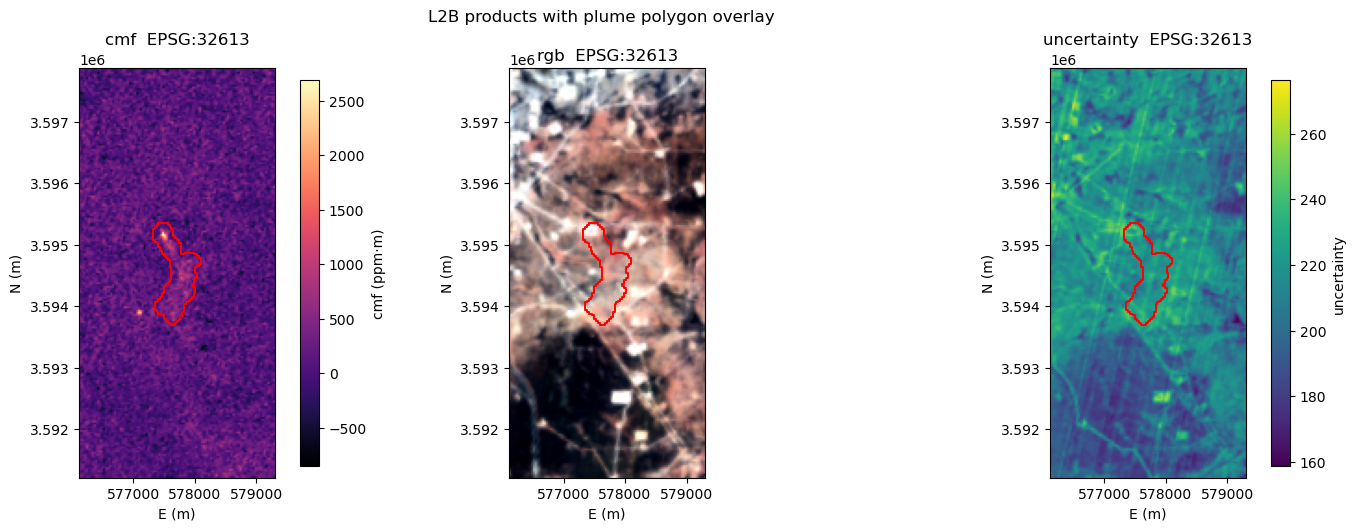

In [12]:
import shapely.affinity as saff
from shapely.geometry import box as shp_box

# 4× padded window for context.
context_window = saff.scale(shp_box(*img.outline.bounds), xfact=4.0, yfact=4.0)
context_crops = ir.read_polygon(
    polygon=context_window,
    bands=("cmf", "rgb", "uncertainty"),
)

panels = [
    ("cmf",         "magma",   "cmf (ppm·m)"),
    ("rgb",         None,      None),
    ("uncertainty", "viridis", "uncertainty"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
for ax, (band, cmap, cbar_label) in zip(axes, panels):
    reader = context_crops[band]
    if reader is None:
        ax.set_axis_off()
        ax.set_title(f"{band} (no overlap)")
        continue
    geo = reader.load()
    arr = np.asarray(geo.values)
    bx = geo.bounds

    if band == "rgb" and arr.ndim == 3 and arr.shape[0] >= 3:
        rgb_img = np.moveaxis(arr[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(rgb_img, [2, 98])
        rgb_img = np.clip((rgb_img - lo) / max(hi - lo, 1e-9), 0, 1)
        ax.imshow(rgb_img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    else:
        a = arr.squeeze().astype("float32")
        nd = reader.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        im = ax.imshow(
            a, extent=(bx[0], bx[2], bx[1], bx[3]),
            origin="upper", cmap=cmap,
        )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    _plot_outline(ax, img.outline, str(geo.crs))
    ax.set_title(f"{band}  {geo.crs}")
    ax.set_xlabel("E (m)")
    ax.set_ylabel("N (m)")
    ax.set_aspect("equal")

fig.suptitle("L2B products with plume polygon overlay")
plt.show()


## 4 · Sources — DBSCAN clusters with stats

`CMSource` is one DBSCAN-clustered point source, addressed by the
deterministic key `{gas}_{sector}_{footprint_m}m_{lon}_{lat}`. One
source aggregates many plumes detected at the same physical site
across many scenes / dates.

Three patterns to know:

1. **`list_sources`** — paginated source listing within a bbox.
2. **`get_source_for_plume`** — resolve plume → source.
3. **`list_plumes_for_source`** — fan out to every detection
   attributed to one source (CSV-backed; full materialisation).

Below we use pattern 2 to find our protagonist plume's source,
then pattern 3 to compute per-source detection statistics.


In [13]:
# Plume → its source (one HTTP, returns None if the plume isn't
# clustered yet — first-detection sites haven't passed DBSCAN).
src = api_queries.get_source_for_plume(TOKEN, PLUME_ID)


def _fmt(v, fmt=""):
    return f"{v:{fmt}}" if v is not None else "—"


if src is None:
    print("plume not yet clustered into a source")
else:
    print(f"source_name  : {src.source_name}")
    print(f"sector       : {src.sector or '—'}")
    print(f"plume_count  : {_fmt(src.plume_count)}")
    print(f"persistence  : {_fmt(src.persistence, '.2f')}")
    print(f"emission_auto: {_fmt(src.emission_auto, '.0f')} kg/h  (site-aggregate)")
    print(f"point        : ({src.point.x:.5f}, {src.point.y:.5f})")


source_name  : CH4_1B2_100m_-104.17525_32.49125
sector       : —
plume_count  : 0
persistence  : 0.00
emission_auto: — kg/h  (site-aggregate)
point        : (-104.17525, 32.49125)


### 4.1 All plumes attributed to a persistent source

Our protagonist plume above sits at a relatively new site (only
1 detection so far). For the stats walkthrough, switch to a
known-persistent Permian oil-and-gas source — 110 detections
across multiple Tanager passes.

`list_plumes_for_source` materialises every detection into a
list of typed `CMRawPlume`s. The endpoint is single-shot (no
pagination); for a typical Permian site this returns a few
hundred records in seconds.


In [14]:
# Switch to a persistent Permian oil-and-gas source for the stats
# demo (the protagonist plume's source has only 1 detection).
DEMO_SOURCE = "CH4_1B2_500m_-103.93835_32.06406"
demo_src = api_queries.get_source(TOKEN, DEMO_SOURCE)
plumes_at_source = api_queries.list_plumes_for_source(TOKEN, DEMO_SOURCE)
print(f"{len(plumes_at_source)} detections at {DEMO_SOURCE}")
print()
print(f"{'plume_id':40s} {'date':10s} {'inst':5s} {'kg/h':>8s}")
print("-" * 70)
for p in plumes_at_source[:6]:
    obs = p.observation_datetime
    date = obs.date().isoformat() if obs else "—"
    em = f"{p.emission_auto:.0f}" if p.emission_auto is not None else "—"
    print(f"{p.plume_id:40s} {date:10s} {p.instrument or '—':5s} {em:>8s}")
if len(plumes_at_source) > 6:
    print(f"... and {len(plumes_at_source) - 6} more")


107 detections at CH4_1B2_500m_-103.93835_32.06406

plume_id                                 date       inst      kg/h
----------------------------------------------------------------------
tan20260311t190317c10s4001-D             2026-03-11 tan        970
emi20250323t212330p14007-F               2025-03-23 emi       1652
av320241004t192754-B                     2024-10-04 av3        209
av320241004t192754-E                     2024-10-04 av3        130
av320241004t192754-F                     2024-10-04 av3         74
av320241004t191153-C                     2024-10-04 av3        140
... and 101 more


### 4.2 Source statistics

Compute a quick site profile from the attributed-plume list:

- detection count + distinct days
- emission distribution (median / p90 / max)
- sensor mix
- date span (first → last detection)

These are the same kinds of stats Carbon Mapper's own source UI
shows; rolling them up locally lets you filter / compare sources
yourself without the UI.


In [15]:
import pandas as pd

# Emissions: filter out the unset / hidden cases
emissions = pd.Series(
    [p.emission_auto for p in plumes_at_source if p.emission_auto is not None],
    name="kg_per_h",
)

# Distinct detection days
detection_dates = sorted({
    p.observation_datetime.date()
    for p in plumes_at_source
    if p.observation_datetime is not None
})

# Sensor mix
sensor_counts = pd.Series(
    [p.instrument for p in plumes_at_source if p.instrument]
).value_counts()


def _fmt(v, fmt=""):
    return f"{v:{fmt}}" if v is not None else "—"


# Pretty print a one-page profile
print(f"=== {demo_src.source_name} ===")
print(f"sector              : {demo_src.sector or '—'}")
print(f"persistence         : {_fmt(demo_src.persistence, '.2f')}")
print(f"site emission_auto  : {_fmt(demo_src.emission_auto, '>8.0f')} kg/h  (CM aggregate)")
print()
print(f"detections          : {len(plumes_at_source)}")
print(f"with emission       : {len(emissions)}")
print(f"distinct days       : {len(detection_dates)}")
if detection_dates:
    print(f"date range          : {detection_dates[0]}  →  {detection_dates[-1]}")
print()
if len(emissions):
    print(f"emission (kg/h):")
    print(emissions.describe(percentiles=[0.5, 0.9, 0.99]).round(0).to_string())
    print()
print(f"sensor mix:")
print(sensor_counts.to_string())


=== CH4_1B2_500m_-103.93835_32.06406 ===
sector              : —
persistence         : 0.00
site emission_auto  : — kg/h  (CM aggregate)

detections          : 107
with emission       : 99
distinct days       : 27
date range          : 2019-10-11  →  2026-03-11

emission (kg/h):
count      99.0
mean      408.0
std       447.0
min        28.0
50%       211.0
90%      1117.0
99%      1805.0
max      1895.0

sensor mix:
GAO    77
av3    26
emi     2
tan     1
ang     1


### 4.3 Visualise — emission timeline

A scatter of every detection's emission rate over time, with the
site-aggregate `emission_auto` from the `CMSource` overlaid.
Helps you eyeball whether the source's headline emission rate is
representative of typical detections, or skewed by a few
super-emitter days.


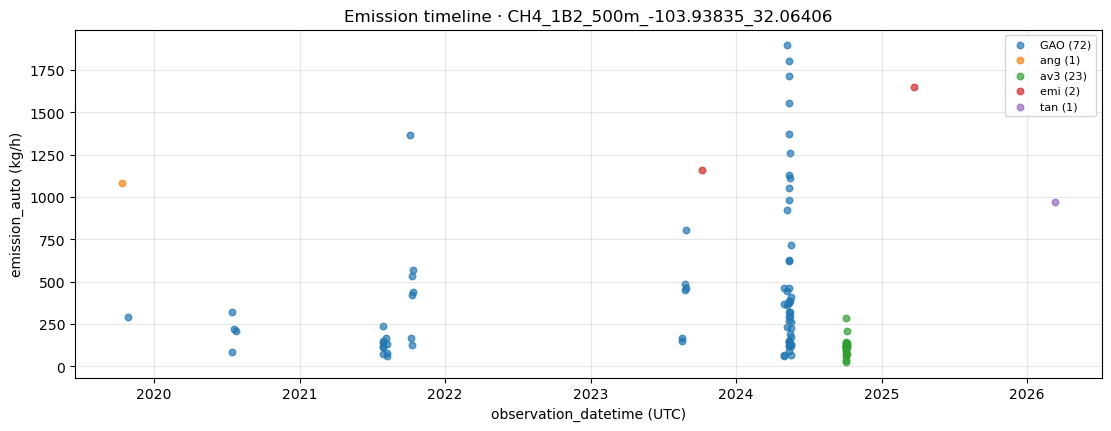

In [16]:
detections_df = pd.DataFrame([
    {
        "datetime": p.observation_datetime,
        "emission_auto": p.emission_auto,
        "instrument": p.instrument,
    }
    for p in plumes_at_source
    if p.observation_datetime is not None
       and p.emission_auto is not None
]).sort_values("datetime")

if len(detections_df) == 0:
    print("no detections with emissions to plot")
else:
    fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
    for inst, subset in detections_df.groupby("instrument"):
        ax.scatter(
            subset["datetime"], subset["emission_auto"],
            label=f"{inst} ({len(subset)})", alpha=0.7, s=22,
        )
    if demo_src.emission_auto is not None:
        ax.axhline(
            demo_src.emission_auto, color="black", linestyle="--", linewidth=1,
            label=f"site emission_auto = {demo_src.emission_auto:.0f} kg/h",
        )
    ax.set_xlabel("observation_datetime (UTC)")
    ax.set_ylabel("emission_auto (kg/h)")
    ax.set_title(f"Emission timeline · {demo_src.source_name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.show()


## See also

- [`api_explore.ipynb`](api_explore.ipynb) — the typed query layer
  in depth (REST + STAC surfaces, filter map, exception
  hierarchy, plume catalog stats).
- [Carbon Mapper Reader API reference](../modules/readers_module.md#carbon-mapper-reader)
  — full module / class / function listing.
- [GeoReader concepts](../modules/read_module.md) — the abstract
  `GeoData` protocol both `RasterioReader` and `GeoTensor` satisfy.
